# ✈️ Flight Delay Analysis — Exploratory Data Analysis (EDA)

This notebook explores the cleaned dataset and produces publication-quality visualizations saved to `images/plots/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')
PLOT_DIR = '../images/plots'
os.makedirs(PLOT_DIR, exist_ok=True)

print('Loading cleaned dataset...')
df = pd.read_csv('../data/flights_clean.csv', low_memory=False, parse_dates=['FL_DATE'])
print(f'Shape: {df.shape}')
df.head()

Loading cleaned dataset...
Shape: (2913802, 37)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,MONTH,DAY_OF_WEEK,HOUR,TIME_OF_DAY,DELAYED
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,NaN,NaN,NaN,NaN,NaN,1,2,11,Morning,0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,NaN,NaN,NaN,NaN,NaN,11,5,21,Evening,0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,NaN,NaN,NaN,NaN,NaN,7,4,9,Morning,0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,0.0,24.0,0.0,0.0,3,0,16,Afternoon,0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,NaN,NaN,NaN,NaN,NaN,2,6,18,Evening,0


## 1. Airline vs Average Departure Delay (Bar Chart)

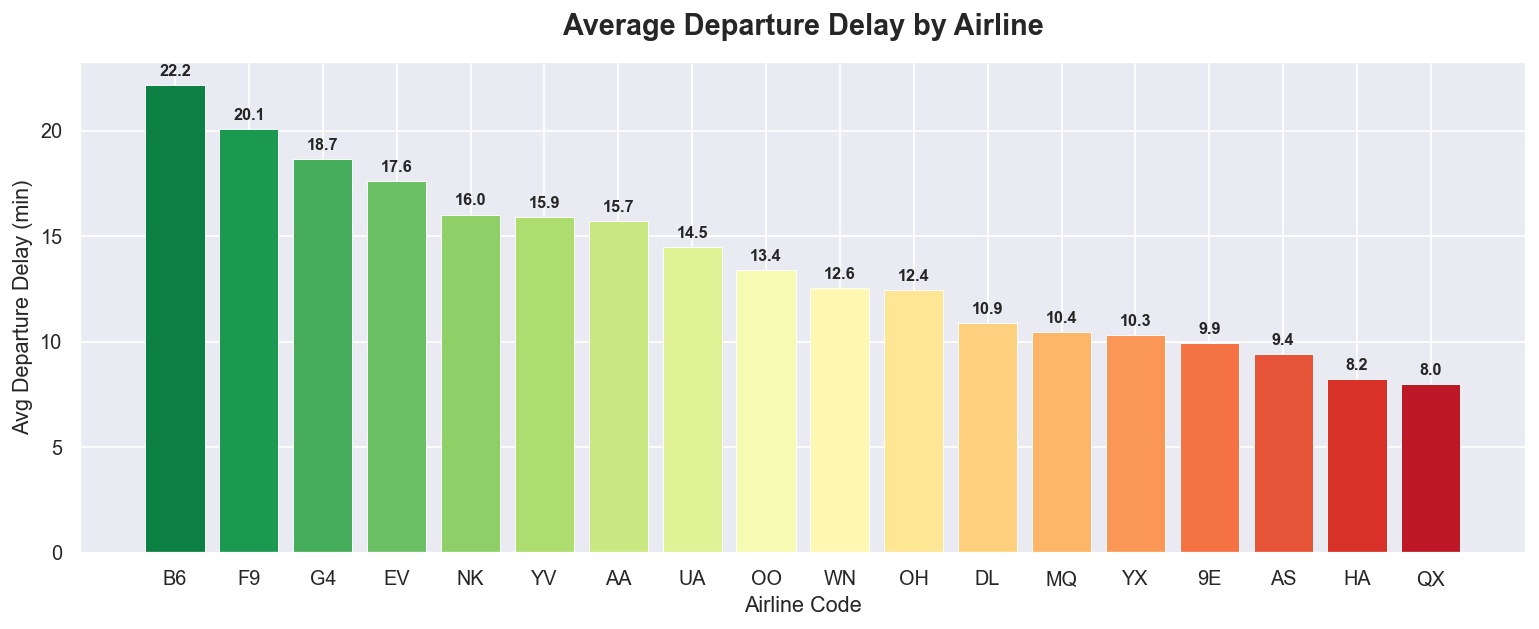

✅ Saved airline_delay_bar.png


In [2]:
airline_delay = (
    df.groupby('AIRLINE_CODE')['DEP_DELAY']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette('RdYlGn_r', len(airline_delay))
bars = ax.bar(airline_delay['AIRLINE_CODE'], airline_delay['DEP_DELAY'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Average Departure Delay by Airline', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Airline Code', fontsize=12)
ax.set_ylabel('Avg Departure Delay (min)', fontsize=12)
for bar, val in zip(bars, airline_delay['DEP_DELAY']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/airline_delay_bar.png', bbox_inches='tight')
plt.show()
print('✅ Saved airline_delay_bar.png')

## 2. Monthly Delay Trend (Line Chart)

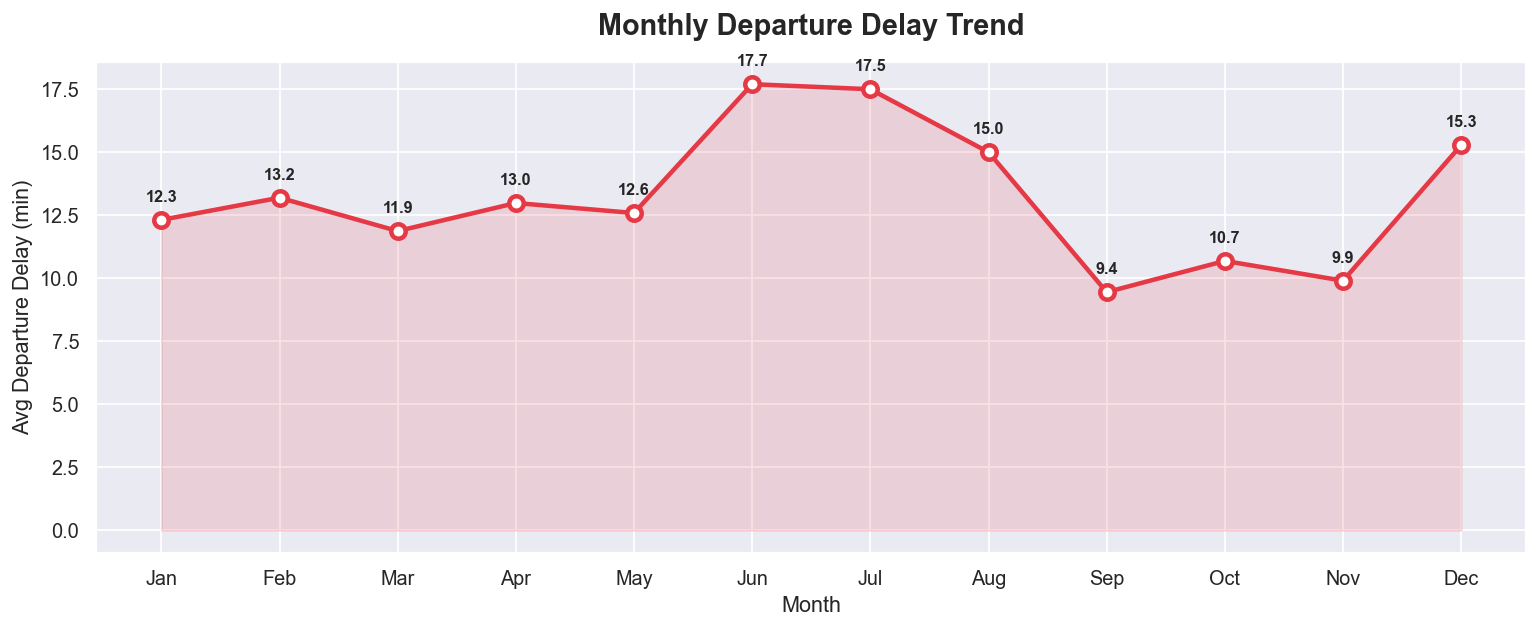

✅ Saved monthly_trend.png


In [3]:
month_delay = df.groupby('MONTH')['DEP_DELAY'].mean().reset_index()
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_delay['MONTH_NAME'] = month_delay['MONTH'].map(month_names)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(month_delay['MONTH_NAME'], month_delay['DEP_DELAY'], marker='o', linewidth=2.5,
        color='#E63946', markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(month_delay['MONTH_NAME'], month_delay['DEP_DELAY'], alpha=0.15, color='#E63946')
ax.set_title('Monthly Departure Delay Trend', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avg Departure Delay (min)', fontsize=12)
for x, y in zip(month_delay['MONTH_NAME'], month_delay['DEP_DELAY']):
    ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/monthly_trend.png', bbox_inches='tight')
plt.show()
print('✅ Saved monthly_trend.png')

## 3. Departure Delay Distribution (Histogram)

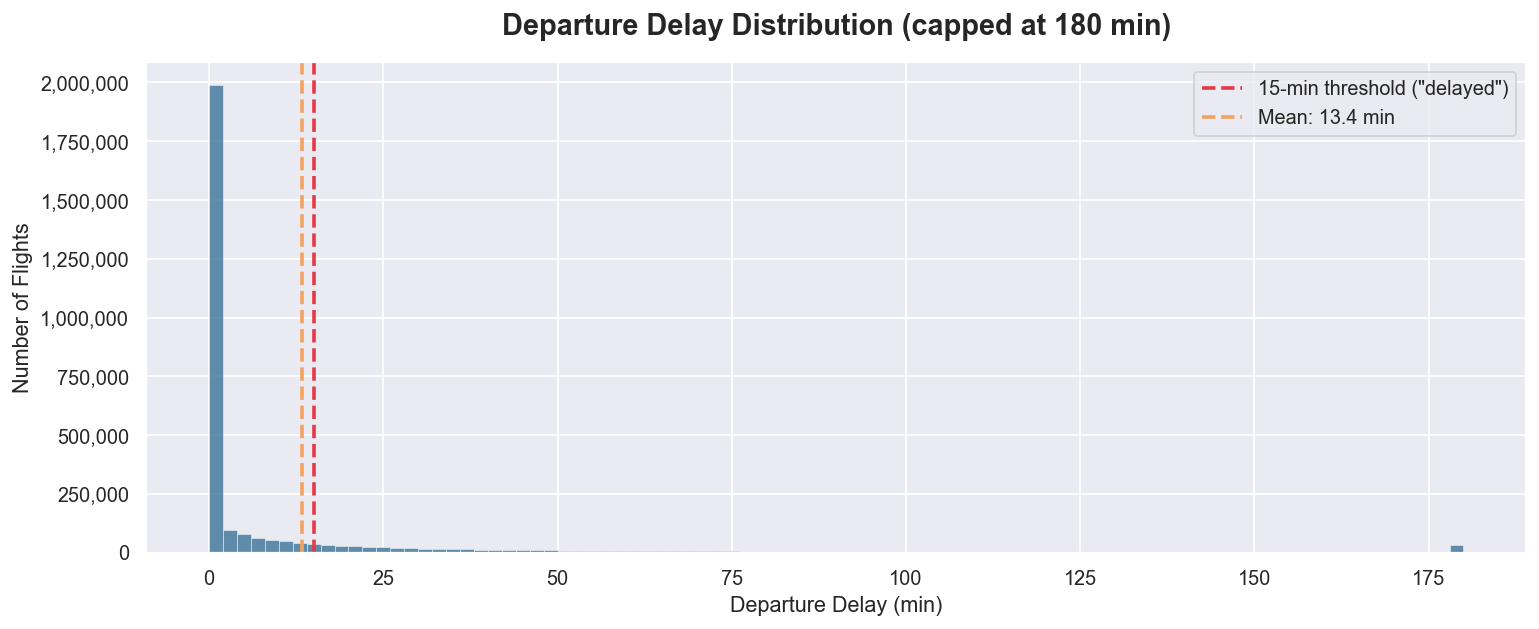

✅ Saved delay_histogram.png


In [4]:
# Cap at 180 min for readability
delay_cap = df['DEP_DELAY'].clip(upper=180)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(delay_cap, bins=90, color='#457B9D', edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(15, color='#E63946', linewidth=2, linestyle='--', label='15-min threshold ("delayed")')
ax.axvline(df['DEP_DELAY'].mean(), color='#F4A261', linewidth=2, linestyle='--',
           label=f'Mean: {df["DEP_DELAY"].mean():.1f} min')
ax.set_title('Departure Delay Distribution (capped at 180 min)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Departure Delay (min)', fontsize=12)
ax.set_ylabel('Number of Flights', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/delay_histogram.png', bbox_inches='tight')
plt.show()
print('✅ Saved delay_histogram.png')

## 4. Correlation Heatmap

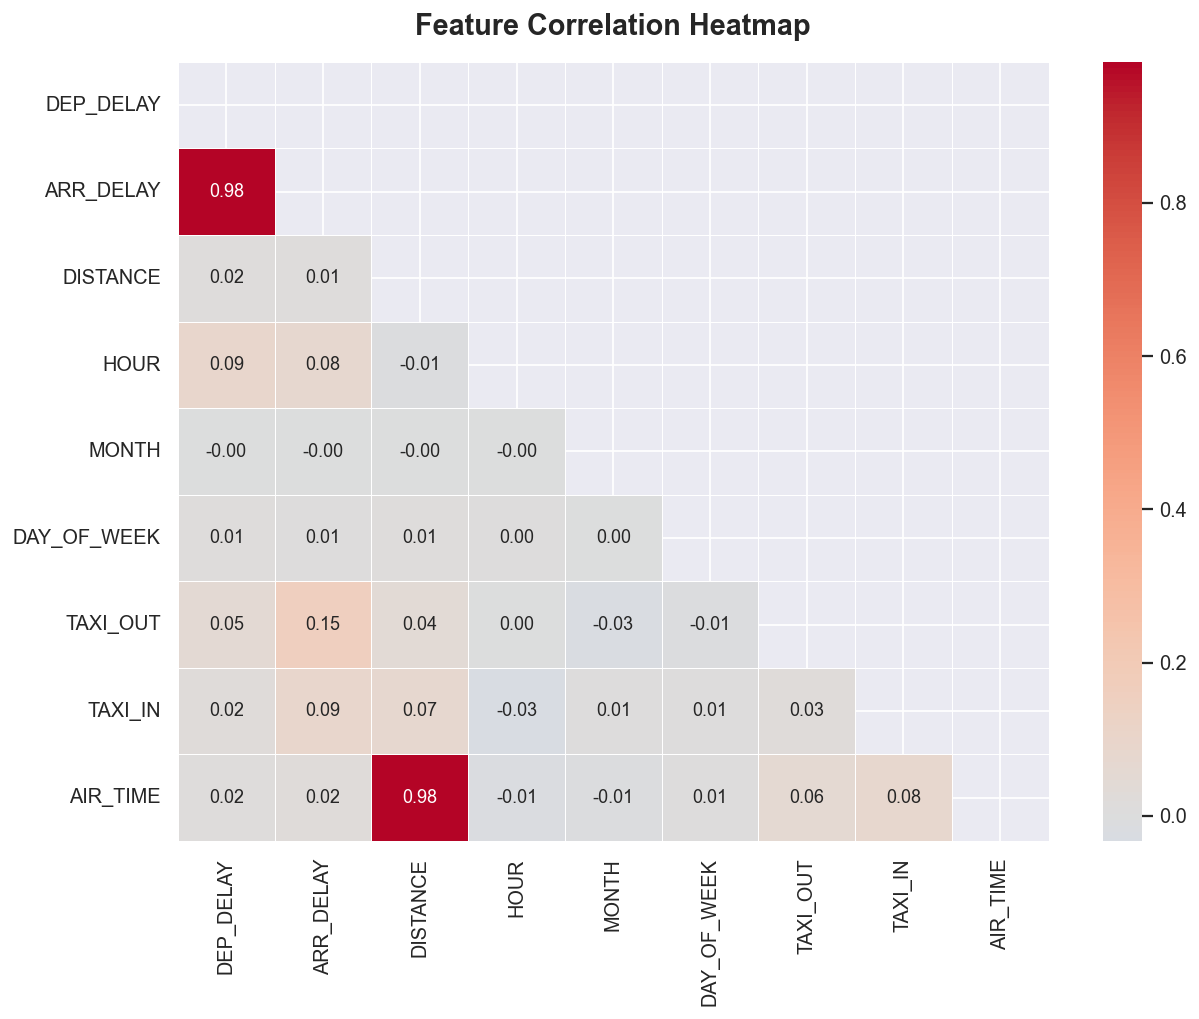

✅ Saved correlation_heatmap.png


In [5]:
num_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'HOUR', 'MONTH',
            'DAY_OF_WEEK', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME']
corr_cols = [c for c in num_cols if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('✅ Saved correlation_heatmap.png')

## 5. Top 20 Most Delayed Airports

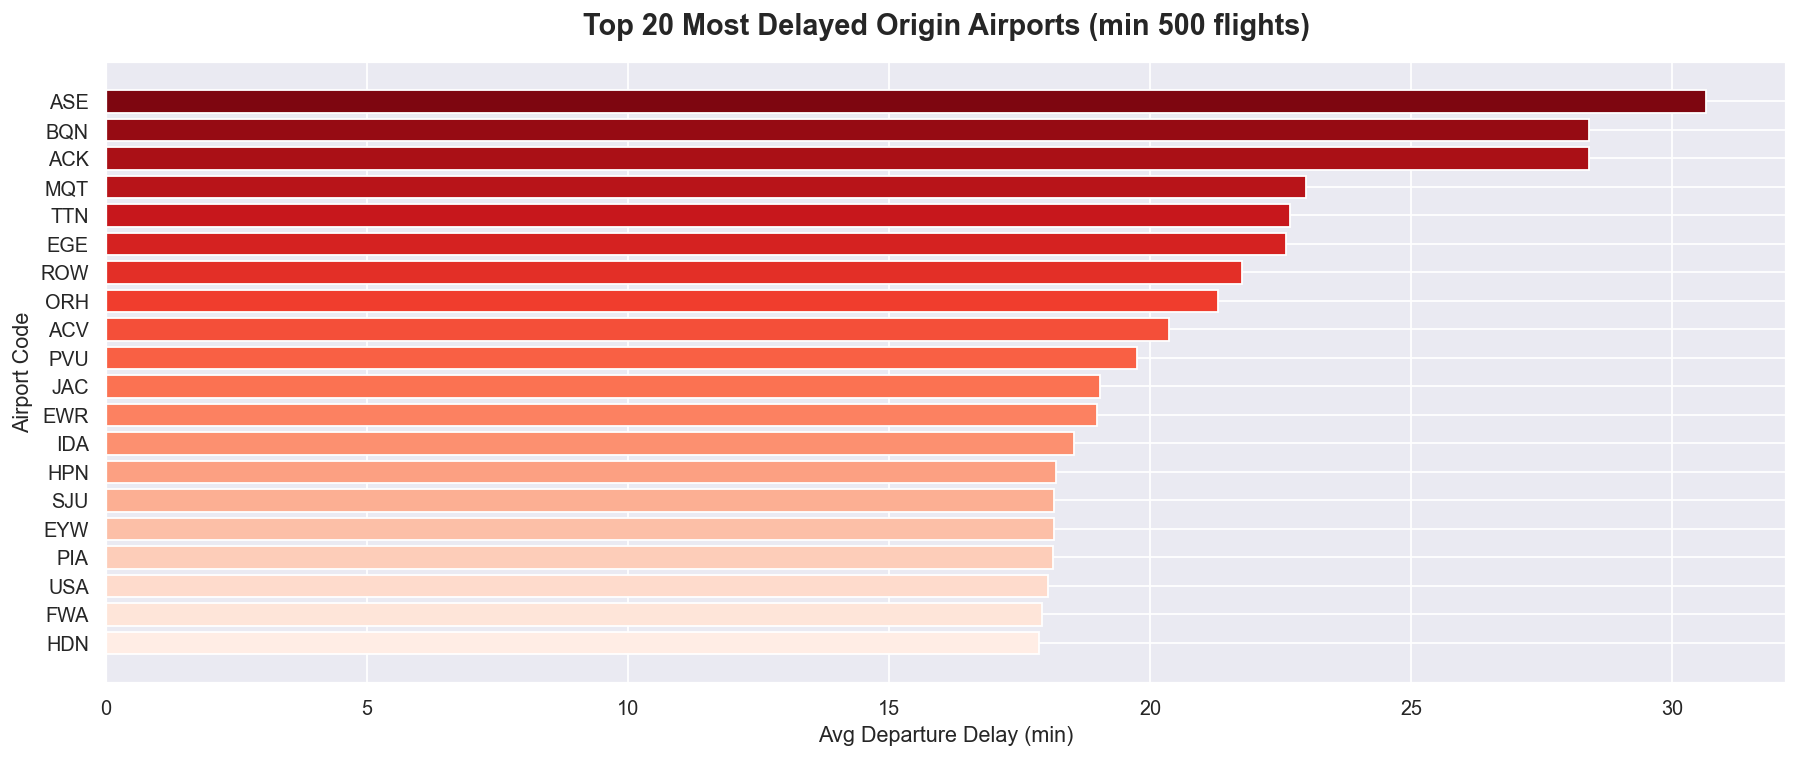

✅ Saved airport_delay.png


In [6]:
airport_delay = (
    df.groupby('ORIGIN')['DEP_DELAY']
    .agg(['mean', 'count'])
    .query('count >= 500')
    .sort_values('mean', ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('Reds_r', len(airport_delay))
ax.barh(airport_delay['ORIGIN'][::-1], airport_delay['mean'][::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Top 20 Most Delayed Origin Airports (min 500 flights)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Avg Departure Delay (min)', fontsize=12)
ax.set_ylabel('Airport Code', fontsize=12)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/airport_delay.png', bbox_inches='tight')
plt.show()
print('✅ Saved airport_delay.png')

## 6. Delay by Time of Day

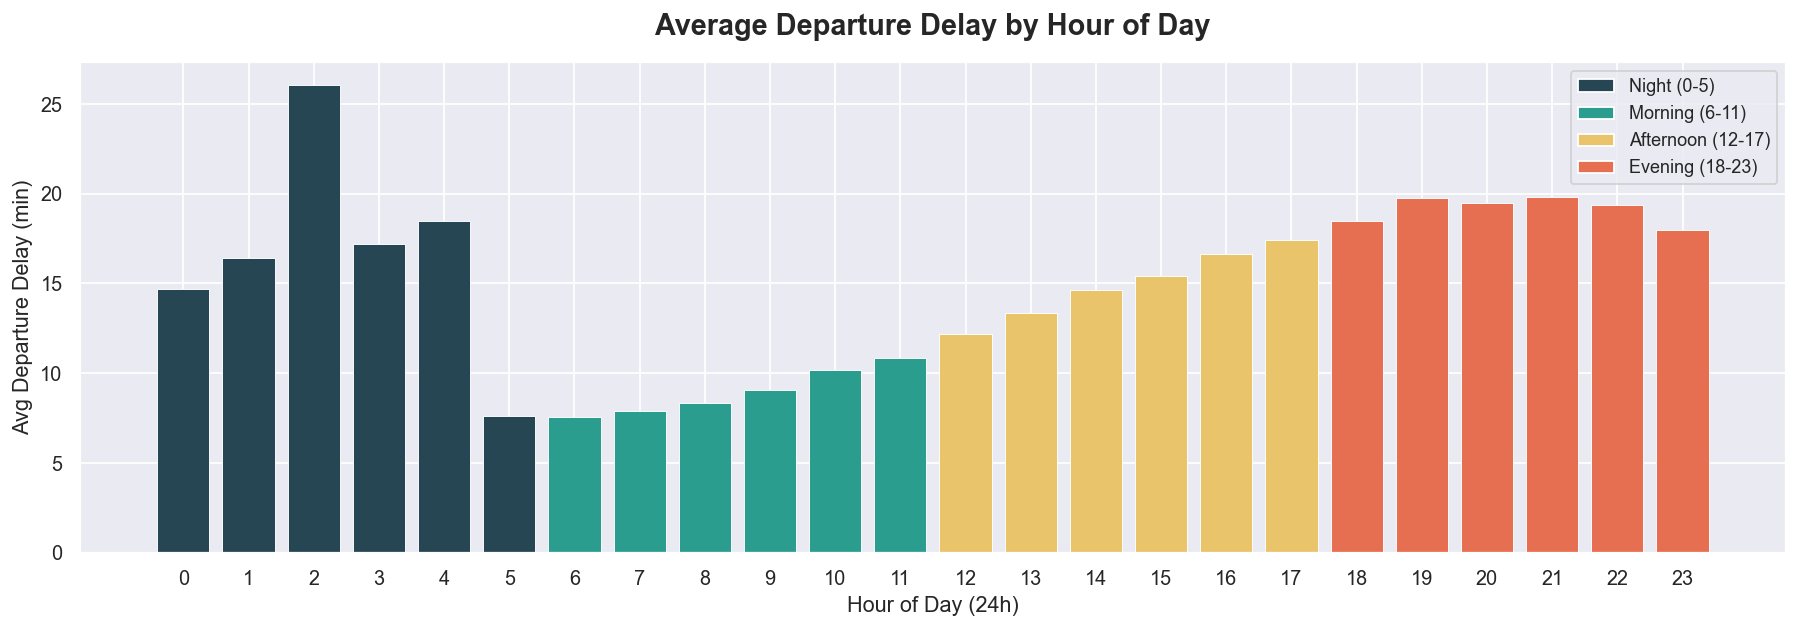

✅ Saved time_of_day_delay.png


In [7]:
hour_delay = df.groupby('HOUR')['DEP_DELAY'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
palette = ['#264653' if h < 6 else '#2A9D8F' if h < 12 else '#E9C46A' if h < 18 else '#E76F51'
           for h in hour_delay['HOUR']]
bars = ax.bar(hour_delay['HOUR'], hour_delay['DEP_DELAY'], color=palette, edgecolor='white', linewidth=0.5)
ax.set_title('Average Departure Delay by Hour of Day', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day (24h)', fontsize=12)
ax.set_ylabel('Avg Departure Delay (min)', fontsize=12)
ax.set_xticks(range(0, 24))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#264653', label='Night (0-5)'),
    Patch(facecolor='#2A9D8F', label='Morning (6-11)'),
    Patch(facecolor='#E9C46A', label='Afternoon (12-17)'),
    Patch(facecolor='#E76F51', label='Evening (18-23)'),
]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/time_of_day_delay.png', bbox_inches='tight')
plt.show()
print('✅ Saved time_of_day_delay.png')

## 7. Delay Cause Breakdown (Pie + Bar)

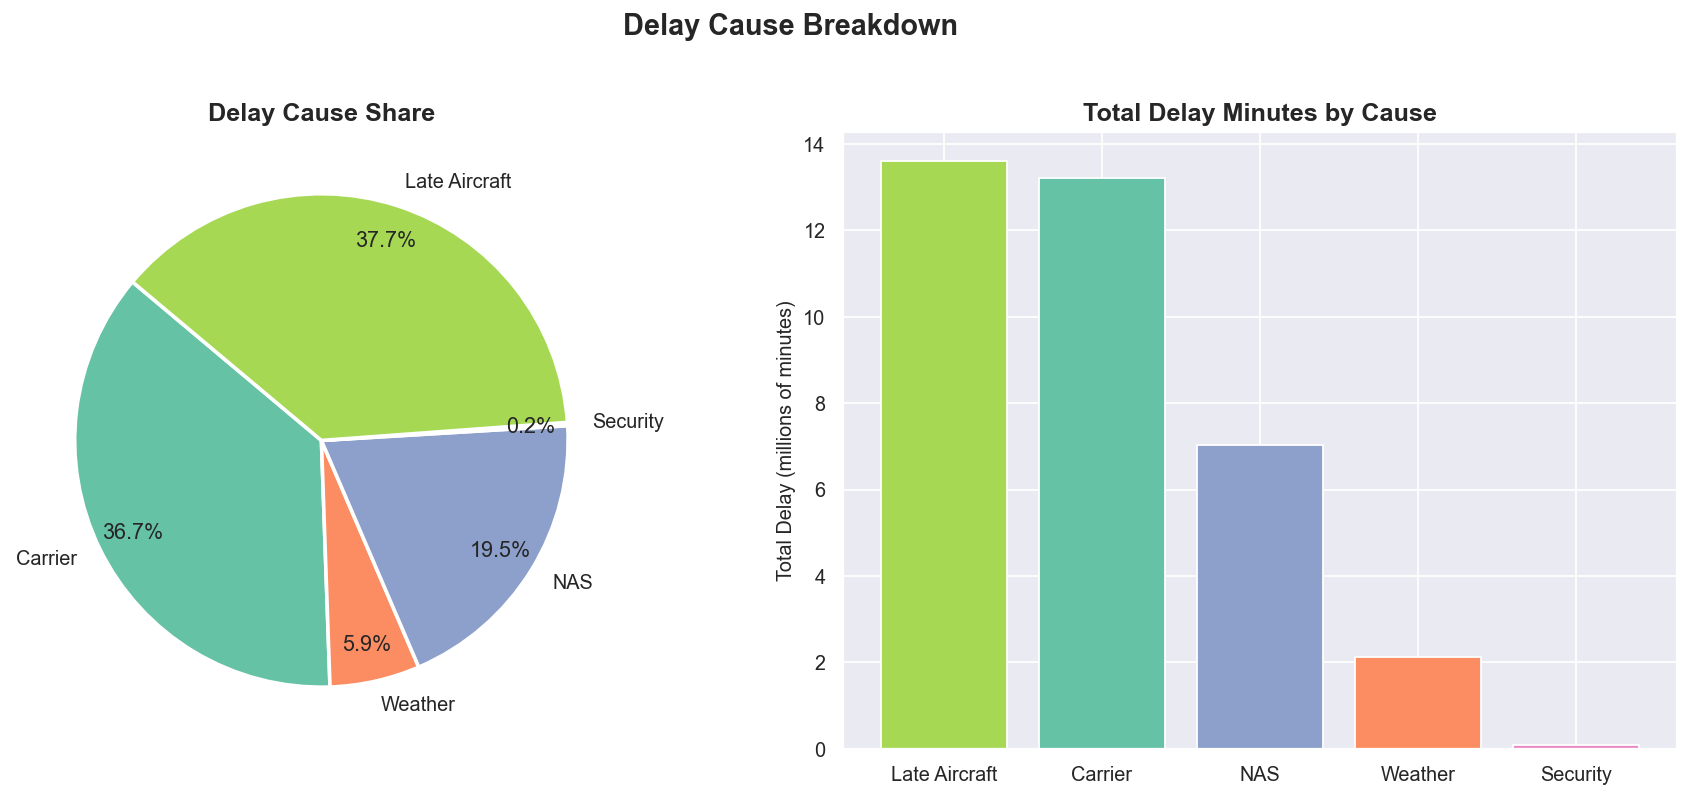

✅ Saved delay_causes.png


In [8]:
cause_cols = ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
              'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']
cause_labels = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']
existing = [(c, l) for c, l in zip(cause_cols, cause_labels) if c in df.columns]

if existing:
    cause_totals = [df[c].sum() for c, l in existing]
    labels = [l for c, l in existing]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    colors = sns.color_palette('Set2', len(labels))

    ax1.pie(cause_totals, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=140, pctdistance=0.85,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax1.set_title('Delay Cause Share', fontsize=14, fontweight='bold')

    sorted_idx = np.argsort(cause_totals)[::-1]
    ax2.bar([labels[i] for i in sorted_idx],
            [cause_totals[i]/1e6 for i in sorted_idx],
            color=[colors[i] for i in sorted_idx], edgecolor='white')
    ax2.set_title('Total Delay Minutes by Cause', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Total Delay (millions of minutes)', fontsize=11)

    plt.suptitle('Delay Cause Breakdown', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/delay_causes.png', bbox_inches='tight')
    plt.show()
    print('✅ Saved delay_causes.png')
else:
    print('Delay cause columns not found — skipping.')

In [9]:
import os
plots = os.listdir(PLOT_DIR)
print(f'\n✅ All plots saved to {PLOT_DIR}:')
for p in sorted(plots):
    print(f'   {p}')


✅ All plots saved to ../images/plots:
   airline_delay_bar.png
   airport_delay.png
   correlation_heatmap.png
   delay_causes.png
   delay_histogram.png
   monthly_trend.png
   time_of_day_delay.png
